# Student's t-Distribution and t-Test

This notebook demonstrates:

- Student's t-distribution
- Effect of degrees of freedom
- One-sample t-test
- t-statistic
- p-value
- Critical t-value
- Hypothesis-test decision

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## 1. Student's t-Distribution

The t-distribution depends on the **degrees of freedom (df)**.

For a one-sample t-test:

$$
df = n - 1
$$

As the degrees of freedom increase, the t-distribution approaches the Standard Normal distribution.

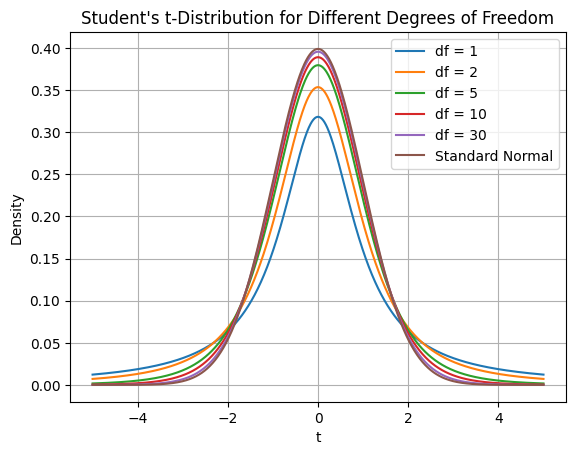

In [2]:
x = np.linspace(-5, 5, 1000)

dfs = [1, 2, 5, 10, 30]

for df in dfs:
    plt.plot(x, stats.t.pdf(x, df), label=f"df = {df}")

plt.plot(x, stats.norm.pdf(x), label="Standard Normal")
plt.title("Student's t-Distribution for Different Degrees of Freedom")
plt.xlabel("t")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

## 2. Degrees of Freedom

For a one-sample t-test:

$$
df = n - 1
$$

For example, if the sample size is:

$$
n = 10
$$

then:

$$
df = 10 - 1 = 9
$$

In [3]:
n = 10
df = n - 1

print("Sample size:", n)
print("Degrees of freedom:", df)

Sample size: 10
Degrees of freedom: 9


## 3. One-Sample t-Test

Suppose:

- Hypothesized population mean = 70
- Sample mean = 72
- Sample standard deviation = 3
- Sample size = 10

We want to test:

$$
H_0: \mu = 70
$$

$$
H_1: \mu \neq 70
$$

The t-statistic is:

$$
t = \frac{\bar{x} - \mu_0}{s/\sqrt{n}}
$$

In [4]:
mu_0 = 70
sample_mean = 72
sample_std = 3
n = 10

t_statistic = (sample_mean - mu_0) / (sample_std / np.sqrt(n))
df = n - 1

print("t-statistic:", t_statistic)
print("Degrees of freedom:", df)

t-statistic: 2.1081851067789197
Degrees of freedom: 9


## 4. Critical t-Value

We use a two-tailed test with:

$$
\alpha = 0.05
$$

Since this is a two-tailed test:

$$
\frac{\alpha}{2} = 0.025
$$

The critical values are:

$$
\pm t_{\text{critical}}
$$

with:

$$
df = 9
$$

In [5]:
alpha = 0.05

t_critical = stats.t.ppf(1 - alpha / 2, df)

print("Critical t-value:", t_critical)
print("Lower critical value:", -t_critical)
print("Upper critical value:", t_critical)

Critical t-value: 2.262157162798205
Lower critical value: -2.262157162798205
Upper critical value: 2.262157162798205


## 5. P-Value

For a two-tailed test, the p-value is the probability of obtaining a t-statistic at least as extreme as the observed value in either direction, assuming \(H_0\) is true.

Decision rule:

$$
p < \alpha \Rightarrow \text{Reject } H_0
$$

$$
p \geq \alpha \Rightarrow \text{Fail to reject } H_0
$$

In [6]:
p_value = 2 * stats.t.sf(abs(t_statistic), df)

print("p-value:", p_value)

p-value: 0.06425884909585156


## 6. Final Decision

We compare the p-value with:

$$
\alpha = 0.05
$$

If:

$$
p < 0.05
$$

we reject \(H_0\).

Otherwise, we fail to reject \(H_0\).

In [7]:
if p_value < alpha:
    print("Reject H0")
    print("There is statistically significant evidence that the population mean differs from 70.")
else:
    print("Fail to reject H0")
    print("There is not enough statistical evidence to conclude that the population mean differs from 70.")

Fail to reject H0
There is not enough statistical evidence to conclude that the population mean differs from 70.


## 7. Using SciPy Directly

Instead of manually calculating the t-statistic and p-value, SciPy provides the `ttest_1samp()` function.

This performs a one-sample t-test directly on the sample data.

In [8]:
sample = np.array([68, 71, 73, 70, 75, 72, 69, 74, 71, 77])

result = stats.ttest_1samp(sample, popmean=70)

print("t-statistic:", result.statistic)
print("p-value:", result.pvalue)

t-statistic: 2.267786838055363
p-value: 0.0495419929614549


## 8. Interpretation

The t-test gives us two important values:

- **t-statistic** → how far the sample mean is from the hypothesized mean in estimated standard-error units.
- **p-value** → how unusual the observed result would be under \(H_0\).

For the two-tailed test:

$$
H_0: \mu = 70
$$

$$
H_1: \mu \neq 70
$$

we compare the p-value with the chosen significance level.

Remember:

> A small p-value provides evidence against \(H_0\); it does not represent the probability that \(H_0\) is true.

## 9. Complete One-Sample t-Test Example

### Medication and IQ

Suppose the population average IQ is:

$$
\mu_0 = 100
$$

Researchers give a new medication to a sample of participants to determine whether the medication affects intelligence.

The sample information is:

$$
n = 30
$$

$$
\bar{x} = 140
$$

$$
s = 20
$$

The confidence level is:

$$
95\%
$$

Therefore:

$$
\alpha = 1 - 0.95 = 0.05
$$

Since the population standard deviation is unknown, we use a **one-sample t-test**.

In [9]:
mu_0 = 100
n = 30
sample_mean = 140
sample_std = 20

confidence_level = 0.95
alpha = 1 - confidence_level

print("Hypothesized population mean:", mu_0)
print("Sample size:", n)
print("Sample mean:", sample_mean)
print("Sample standard deviation:", sample_std)
print("Confidence level:", confidence_level)
print("Significance level:", alpha)

Hypothesized population mean: 100
Sample size: 30
Sample mean: 140
Sample standard deviation: 20
Confidence level: 0.95
Significance level: 0.050000000000000044


## 10. State the Hypotheses

The researchers want to determine whether the medication has either a positive or negative effect.

Therefore, this is a **two-tailed test**.

### Null Hypothesis

$$
H_0: \mu = 100
$$

### Alternative Hypothesis

$$
H_1: \mu \neq 100
$$

We are checking whether:

$$
\mu > 100
$$

or:

$$
\mu < 100
$$

## 11. Calculate Degrees of Freedom

For a one-sample t-test:

$$
df = n - 1
$$

In [10]:
df = n - 1

print("Degrees of freedom:", df)

Degrees of freedom: 29


## 12. Determine the Critical t-Value

We have:

- Confidence level = 95%
- Significance level \(\alpha = 0.05\)
- Two-tailed test
- \(df = 29\)

For a two-tailed test:

$$
\frac{\alpha}{2} = \frac{0.05}{2} = 0.025
$$

The critical t-value is:

$$
t_{\text{critical}} \approx \pm 2.045
$$

In [11]:
t_critical = stats.t.ppf(1 - alpha / 2, df)

print("Critical t-value:", t_critical)
print("Lower critical value:", -t_critical)
print("Upper critical value:", t_critical)

Critical t-value: 2.045229642132704
Lower critical value: -2.045229642132704
Upper critical value: 2.045229642132704


## 13. Calculate the t-Statistic

The one-sample t-test formula is:

$$
t = \frac{\bar{x} - \mu_0}{s/\sqrt{n}}
$$

Substituting the values:

$$
t = \frac{140 - 100}{20/\sqrt{30}}
$$

In [12]:
t_statistic = (sample_mean - mu_0) / (sample_std / np.sqrt(n))

print("t-statistic:", t_statistic)

t-statistic: 10.954451150103322


## 14. Critical-Value Decision

The critical values are approximately:

$$
\pm 2.045
$$

The observed t-statistic is:

$$
t \approx 10.95
$$

Decision rule:

$$
|t| > t_{\text{critical}}
\Rightarrow
\text{Reject }H_0
$$

Since:

$$
|10.95| > 2.045
$$

the test statistic lies in the rejection region.

Therefore:

$$
\boxed{\text{Reject }H_0}
$$

In [14]:
if abs(t_statistic) > t_critical:
    decision = "Reject H0"
else:
    decision = "Fail to reject H0"

print("t-statistic:", t_statistic)
print("Critical t-value:", t_critical)
print("Decision:", decision)

t-statistic: 10.954451150103322
Critical t-value: 2.045229642132704
Decision: Reject H0


## 15. P-Value Approach

For a two-tailed t-test:

$$
p = P(|T| \geq |t_{\text{observed}}| \mid H_0)
$$

We compare the p-value with:

$$
\alpha = 0.05
$$

Decision rule:

$$
p < \alpha
\Rightarrow
\text{Reject }H_0
$$

$$
p \geq \alpha
\Rightarrow
\text{Fail to reject }H_0
$$

In [16]:
p_value = 2 * stats.t.sf(abs(t_statistic), df)

print("P-value:", p_value)

P-value: 8.02128714022661e-12


## 16. P-Value Decision

In [17]:
if p_value < alpha:
    print("Reject H0")
    print("The result is statistically significant at alpha = 0.05.")
else:
    print("Fail to reject H0")
    print("The result is not statistically significant at alpha = 0.05.")

Reject H0
The result is statistically significant at alpha = 0.05.


## 17. Critical-Value vs P-Value Approach

Both approaches should lead to the same conclusion.

### Critical-Value Approach

$$
|t| > t_{\text{critical}}
\Rightarrow
\text{Reject }H_0
$$

### P-Value Approach

$$
p < \alpha
\Rightarrow
\text{Reject }H_0
$$

For this example:

$$
t \approx 10.95
$$

and:

$$
t_{\text{critical}} \approx 2.045
$$

Therefore:

$$
10.95 > 2.045
$$

and the p-value is extremely small.

Thus:

$$
\boxed{\text{Reject }H_0}
$$

## 18. Final Conclusion

The null hypothesis was:

$$
H_0: \mu = 100
$$

We rejected H₀.

Therefore, there is sufficient statistical evidence to conclude that the population mean IQ differs from 100 under the assumptions of the test.

The sample mean is:

$$
\bar{x} = 140
$$

which is greater than the hypothesized mean:

$$
140 > 100
$$

Therefore, the observed effect in this sample is in the **positive direction**.

### Important

The statistical test alone does **not prove that the medication causes an increase in intelligence**.

A causal conclusion would require an appropriate experimental design and consideration of other factors.

## 19. Complete One-Sample t-Test Flow

```text
Population standard deviation unknown
                ↓
        One-Sample t-Test
                ↓
        State H₀ and H₁
                ↓
   Identify one/two-tailed test
                ↓
          Choose α
                ↓
       Calculate df = n − 1
                ↓
    Find critical t-value
                ↓
      Calculate t-statistic
                ↓
Compare t-statistic with critical value
                ↓
   Reject / Fail to reject H₀
                ↓
      Interpret the result


## 20. Summary

For the Medication and IQ example:

| Parameter | Value |
|---|---:|
| Hypothesized mean \(\mu_0\) | 100 |
| Sample size \(n\) | 30 |
| Sample mean \(\bar{x}\) | 140 |
| Sample standard deviation \(s\) | 20 |
| Confidence level | 95% |
| Significance level \(\alpha\) | 0.05 |
| Degrees of freedom | 29 |
| Critical t-value | \(\pm 2.045\) |
| t-statistic | \(\approx 10.95\) |

Decision:

$$
\boxed{\text{Reject }H_0}
$$

There is sufficient statistical evidence that the population mean differs from 100, with the observed sample effect in the positive direction.